<a href="https://colab.research.google.com/github/JAYMAN735/ML-Projects/blob/main/Experiment1_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
ex = pd.read_excel("/content/india_visualization_dataset.xlsx")
ex


,State,Year,GDP,Population,Unemployment,Latitude,Longitude
0,Maharashtra,2015,101,63,7.24,18.780503,72.364282
1,Maharashtra,2016,120,11,7.58,10.697283,89.167311
2,Maharashtra,2017,114,33,11.55,22.022387,84.934460
3,Maharashtra,2018,121,61,3.27,8.678431,83.220091
4,Maharashtra,2019,137,51,8.26,11.307662,79.472690
5,Maharashtra,2020,123,23,5.11,16.948316,88.120232
6,Maharashtra,2021,131,42,9.52,13.438000,71.226634
7,Maharashtra,2022,146,52,8.01,24.723757,85.678891
8,Maharashtra,2023,143,77,11.96,10.148723,73.103042
9,Maharashtra,2024,145,75,9.96,27.695639,73.832745


In [ ]:
js = pd.read_json("/content/india_visualization_dataset.json")
js


,State,Year,GDP,Population,Unemployment,Latitude,Longitude
0,Maharashtra,2015,98,56,9.71,20.661407,73.239414
1,Maharashtra,2016,107,71,3.22,16.695191,89.039162
2,Maharashtra,2017,103,20,9.41,10.215799,84.503671
3,Maharashtra,2018,120,71,11.78,25.666914,77.005624
4,Maharashtra,2019,111,14,8.79,14.112689,75.980478
5,Maharashtra,2020,110,47,7.19,14.787350,75.194904
6,Maharashtra,2021,113,16,9.37,11.369779,86.049953
7,Maharashtra,2022,133,79,10.09,11.582929,88.097437
8,Maharashtra,2023,129,10,4.26,12.142273,71.188987
9,Maharashtra,2024,154,27,6.00,27.709110,86.373916


In [ ]:
import sqlite3
import pandas as pd
conn = sqlite3.connect("india_data.db")
with open("india_visualization_dataset.sql", "r") as file:
    sql_script = file.read()
conn.executescript(sql_script)
df = pd.read_sql_query("SELECT * FROM india_data", conn)
print(df.head())
conn.close()


         State  Year    GDP  Population  Unemployment   Latitude  Longitude
0  Maharashtra  2015   98.0          56          9.71  20.661407  73.239414
1  Maharashtra  2016  107.0          71          3.22  16.695191  89.039162
2  Maharashtra  2017  103.0          20          9.41  10.215799  84.503671
3  Maharashtra  2018  120.0          71         11.78  25.666914  77.005624
4  Maharashtra  2019  111.0          14          8.79  14.112689  75.980478


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "http://books.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")
books = soup.find_all("article", class_="product_pod")

data = []
for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text
    data.append({
        "Title": title,
        "Price": price
    })

df = pd.DataFrame(data)
df.to_csv("books_data.csv", index=False)
df.to_excel("books_data.xlsx", index=False)
print(df.head())

                                   Title    Price
0                   A Light in the Attic  Â£51.77
1                     Tipping the Velvet  Â£53.74
2                             Soumission  Â£50.10
3                          Sharp Objects  Â£47.82
4  Sapiens: A Brief History of Humankind  Â£54.23


In [ ]:
df=pd.read_csv('/content/used_cars_data.csv')

In [ ]:
df.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [ ]:
df.describe()

,S.No.,Year,Kilometers_Driven,Seats,Price
count,7253.000000,7253.000000,7.253000e+03,7200.000000,6019.000000
mean,3626.000000,2013.365366,5.869906e+04,5.279722,9.479468
std,2093.905084,3.254421,8.442772e+04,0.811660,11.187917
min,0.000000,1996.000000,1.710000e+02,0.000000,0.440000
25%,1813.000000,2011.000000,3.400000e+04,5.000000,3.500000
50%,3626.000000,2014.000000,5.341600e+04,5.000000,5.640000
75%,5439.000000,2016.000000,7.300000e+04,5.000000,9.950000
max,7252.000000,2019.000000,6.500000e+06,10.000000,160.000000


In [ ]:
print(df.isnull().sum())

S.No.                   0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                  46
Seats                  53
New_Price            6247
Price                1234
dtype: int64


In [ ]:
df = df.drop('New_Price', axis=1)
print('Dropped New_Price column. Remaining missing values:')
print(df.isnull().sum())

Dropped New_Price column. Remaining missing values:
S.No.                   0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                  46
Seats                  53
Price                1234
dtype: int64


In [ ]:
# Identify rows with 'Electric' fuel type
rows_to_delete_electric = df[df['Fuel_Type'] == 'Electric'].index

# Drop the identified rows from the DataFrame
df = df.drop(rows_to_delete_electric)

print("Entries with 'Electric' fuel type deleted.")

# Display the remaining missing values for all columns to show the updated state
print('Remaining missing values:')
print(df.isnull().sum())

Entries with 'Electric' fuel type deleted.
Remaining missing values:
S.No.                   0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 0
Engine                 46
Power                  46
Seats                  53
Price                1234
dtype: int64


In [ ]:
# Impute missing 'Price' values with the median
median_price = df['Price'].median() # Re-calculate just in case, though it was done before
df['Price'].fillna(median_price, inplace=True)

print(f"Median Price used for imputation: {median_price:.2f}")
print('\nMissing values after imputing Price column:')
print(df['Price'].isnull().sum())

Median Price used for imputation: 5.64

Missing values after imputing Price column:
0


/tmp/ipykernel_1070/599005594.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Price'].fillna(median_price, inplace=True)


In [ ]:
df['Seats'].fillna(5, inplace=True)
print('Missing values after imputing Seats column with 5:')
print(df['Seats'].isnull().sum())

Missing values after imputing Seats column with 5:
0


/tmp/ipykernel_1070/3034938533.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Seats'].fillna(5, inplace=True)


In [ ]:
# Clean 'Engine' column: remove ' CC' and convert 'null CC' to NaN
df['Engine'] = df['Engine'].astype(str).str.replace(' CC', '', regex=False)
df['Engine'] = df['Engine'].str.replace('null', 'NaN', regex=False)

# Convert 'Engine' to numeric, coercing errors to NaN
df['Engine'] = pd.to_numeric(df['Engine'], errors='coerce')

# Calculate the mean for 'Engine'
mean_engine = df['Engine'].mean()

# Impute missing values with the calculated mean
df['Engine'] = df['Engine'].fillna(mean_engine)

print(f"Mean Engine used for imputation: {mean_engine:.2f} CC")
print('\nMissing values after imputing Engine column:')
print(df['Engine'].isnull().sum())

Mean Engine used for imputation: 1616.76 CC

Missing values after imputing Engine column:
0


In [ ]:
# Clean 'Power' column: remove ' bhp' and convert 'null bhp' to NaN
df['Power'] = df['Power'].astype(str).str.replace(' bhp', '', regex=False)
df['Power'] = df['Power'].str.replace('null', 'NaN', regex=False)

# Convert 'Power' to numeric, coercing errors to NaN
df['Power'] = pd.to_numeric(df['Power'], errors='coerce')

# Calculate the mean for 'Power'
mean_power = df['Power'].mean()

# Impute missing values with the calculated mean
df['Power'] = df['Power'].fillna(mean_power)

print(f"Mean Power used for imputation: {mean_power:.2f} bhp")
print('\nMissing values after imputing Power column:')
print(df['Power'].isnull().sum())

Mean Power used for imputation: 112.78 bhp

Missing values after imputing Power column:
0


In [ ]:
print(df.isnull().sum())

S.No.                0
Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
dtype: int64


In [ ]:
# Extract car brand from 'Name' column
df['Brand'] = df['Name'].apply(lambda x: x.split(' ')[0])

print("Top 10 car brands extracted:")
print(df['Brand'].value_counts().head(10))

print("\nDataFrame with new 'Brand' column:")
display(df.head())

Top 10 car brands extracted:
Brand
Maruti           1444
Hyundai          1340
Honda             743
Toyota            506
Mercedes-Benz     380
Volkswagen        374
Ford              351
Mahindra          330
BMW               312
Audi              285
Name: count, dtype: int64

DataFrame with new 'Brand' column:


,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998.0,58.16,5.0,1.75,Maruti
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582.0,126.20,5.0,12.50,Hyundai
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199.0,88.70,5.0,4.50,Honda
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248.0,88.76,7.0,6.00,Maruti
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968.0,140.80,5.0,17.74,Audi


In [ ]:
print(df['Brand'].unique())

['Maruti' 'Hyundai' 'Honda' 'Audi' 'Nissan' 'Toyota' 'Volkswagen' 'Tata'
 'Land' 'Mitsubishi' 'Renault' 'Mercedes-Benz' 'BMW' 'Mahindra' 'Ford'
 'Porsche' 'Datsun' 'Jaguar' 'Volvo' 'Chevrolet' 'Skoda' 'Mini' 'Fiat'
 'Jeep' 'Smart' 'Ambassador' 'Isuzu' 'ISUZU' 'Force' 'Bentley'
 'Lamborghini' 'Hindustan' 'OpelCorsa']


In [ ]:
df['Brand'] = df['Brand'].replace('ISUZU', 'Isuzu')
print(df['Brand'].unique())

['Maruti' 'Hyundai' 'Honda' 'Audi' 'Nissan' 'Toyota' 'Volkswagen' 'Tata'
 'Land' 'Mitsubishi' 'Renault' 'Mercedes-Benz' 'BMW' 'Mahindra' 'Ford'
 'Porsche' 'Datsun' 'Jaguar' 'Volvo' 'Chevrolet' 'Skoda' 'Mini' 'Fiat'
 'Jeep' 'Smart' 'Ambassador' 'Isuzu' 'Force' 'Bentley' 'Lamborghini'
 'Hindustan' 'OpelCorsa']


In [ ]:
print('Original DataFrame Info:')
df.info()

# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns
print(f"\nCategorical columns identified: {list(categorical_cols)}")

# Display unique values and their counts for each categorical column to decide on encoding
for col in categorical_cols:
    print(f"\nUnique values in '{col}':")
    print(df[col].value_counts())

Original DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 7251 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7251 non-null   int64  
 1   Name               7251 non-null   object 
 2   Location           7251 non-null   object 
 3   Year               7251 non-null   int64  
 4   Kilometers_Driven  7251 non-null   int64  
 5   Fuel_Type          7251 non-null   object 
 6   Transmission       7251 non-null   object 
 7   Owner_Type         7251 non-null   object 
 8   Mileage            7251 non-null   object 
 9   Engine             7251 non-null   float64
 10  Power              7251 non-null   float64
 11  Seats              7251 non-null   float64
 12  Price              7251 non-null   float64
 13  Brand              7251 non-null   object 
dtypes: float64(4), int64(3), object(7)
memory usage: 849.7+ KB

Categorical columns identified: ['Name',

In [ ]:
print(f"Number of duplicate rows before dropping: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)

print(f"Number of duplicate rows after dropping: {df.duplicated().sum()}")

Number of duplicate rows before dropping: 0
Number of duplicate rows after dropping: 0


In [ ]:
owner_type_by_brand = pd.crosstab(df['Brand'], df['Owner_Type'])
print("Number of Owner Types by Brand:")
display(owner_type_by_brand)

Number of Owner Types by Brand:


Owner_Type,First,Fourth & Above,Second,Third
Brand,,,,
Ambassador,0,0,0,1
Audi,228,0,54,3
BMW,243,0,61,8
Bentley,1,0,1,0
Chevrolet,109,0,33,9
Datsun,17,0,0,0
Fiat,27,0,9,2
Force,3,0,0,0
Ford,277,2,60,12


In [ ]:
# Calculate the total number of cars for each brand
owner_type_by_brand['Total'] = owner_type_by_brand.sum(axis=1)

# Sort the DataFrame by the 'Total' column in descending order
sorted_owner_type_by_brand = owner_type_by_brand.sort_values(by='Total', ascending=False)

# Display the sorted DataFrame, dropping the temporary 'Total' column for clarity if not explicitly requested
display(sorted_owner_type_by_brand.drop(columns='Total'))

Owner_Type,First,Fourth & Above,Second,Third
Brand,,,,
Maruti,1225,4,190,25
Hyundai,1114,2,203,21
Honda,609,0,113,21
Toyota,406,3,86,11
Mercedes-Benz,313,0,65,2
Volkswagen,316,0,52,6
Ford,277,2,60,12
Mahindra,272,0,51,7
BMW,243,0,61,8


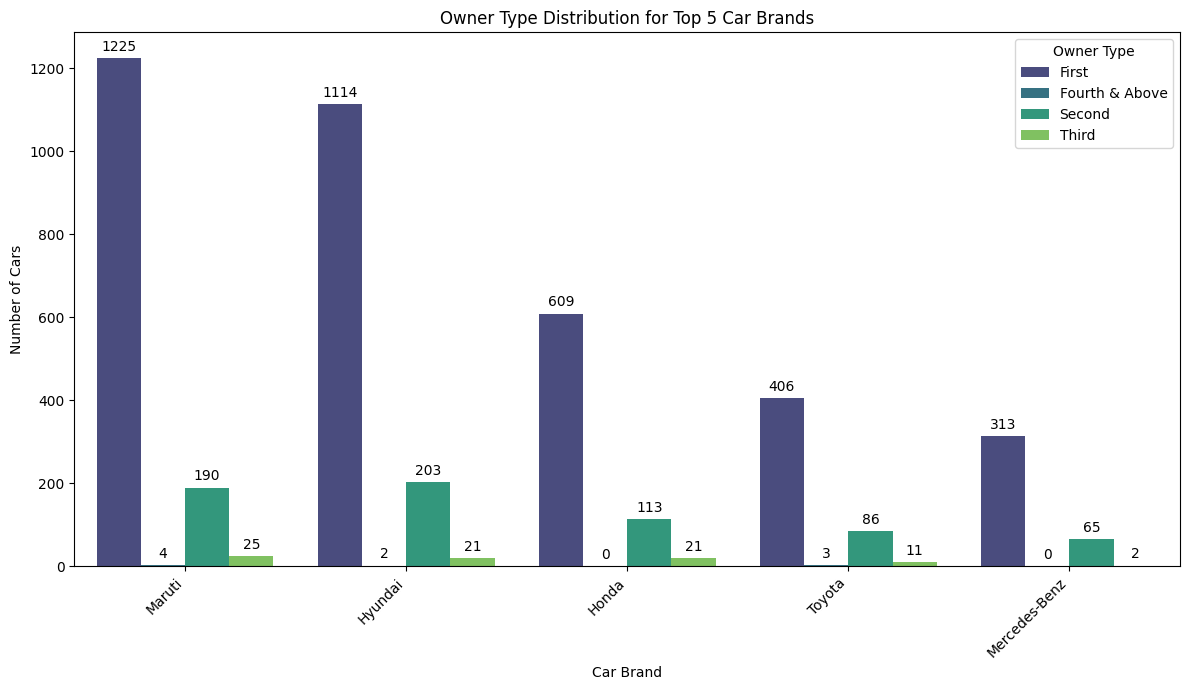

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 5 brands from the sorted DataFrame
top_5_brands = sorted_owner_type_by_brand.head(5)

# Drop the 'Total' column as it's not needed for the owner type distribution plot
top_5_brands_data = top_5_brands.drop(columns='Total')

# Reshape the data for plotting (melt it)
top_5_brands_melted = top_5_brands_data.reset_index().melt(id_vars='Brand', var_name='Owner_Type', value_name='Count')

plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Brand', y='Count', hue='Owner_Type', data=top_5_brands_melted, palette='viridis')
plt.title('Owner Type Distribution for Top 5 Car Brands')
plt.xlabel('Car Brand')
plt.ylabel('Number of Cars')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Owner Type')

# Add labels on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

In [ ]:
df.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998.0,58.16,5.0,1.75,Maruti
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582.0,126.20,5.0,12.50,Hyundai
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199.0,88.70,5.0,4.50,Honda
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248.0,88.76,7.0,6.00,Maruti
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968.0,140.80,5.0,17.74,Audi


In [ ]:
df['Mileage'] = df['Mileage'].astype(str).str.replace(' kmpl', '', regex=False)
df['Mileage'] = df['Mileage'].astype(str).str.replace(' km/kg', '', regex=False)

df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')

mean_mileage = df['Mileage'].mean()
df['Mileage'].fillna(mean_mileage, inplace=True)

print(f"Mean Mileage used for imputation: {mean_mileage:.2f}")
print('\nMissing values after imputing Mileage column:')
print(df['Mileage'].isnull().sum())

Mean Mileage used for imputation: 18.14

Missing values after imputing Mileage column:
0


/tmp/ipykernel_1070/2782163319.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Mileage'].fillna(mean_mileage, inplace=True)


In [ ]:
df['Mileage'] = df['Mileage'].astype(str).str.replace(' kmpl', '', regex=False)
df['Mileage'] = df['Mileage'].astype(str).str.replace(' km/kg', '', regex=False)

df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')

mean_mileage = df['Mileage'].mean()
df['Mileage'] = df['Mileage'].fillna(mean_mileage)

print(f"Mean Mileage used for imputation: {mean_mileage:.2f}")
print('\nMissing values after imputing Mileage column:')
print(df['Mileage'].isnull().sum())

Mean Mileage used for imputation: 18.14

Missing values after imputing Mileage column:
0


In [ ]:
mileage_by_brand_owner = df.groupby(['Brand', 'Owner_Type'])['Mileage'].mean().reset_index()

top_5_brands_list = sorted_owner_type_by_brand.head(5).index.tolist()

mileage_top_5_brands = mileage_by_brand_owner[mileage_by_brand_owner['Brand'].isin(top_5_brands_list)]

print("Average Mileage by Owner Type for Top 5 Brands:")
display(mileage_top_5_brands.head())

Average Mileage by Owner Type for Top 5 Brands:


,Brand,Owner_Type,Mileage
22,Honda,First,19.047455
23,Honda,Second,16.271681
24,Honda,Third,13.080952
25,Hyundai,First,19.016293
26,Hyundai,Fourth & Above,8.500000


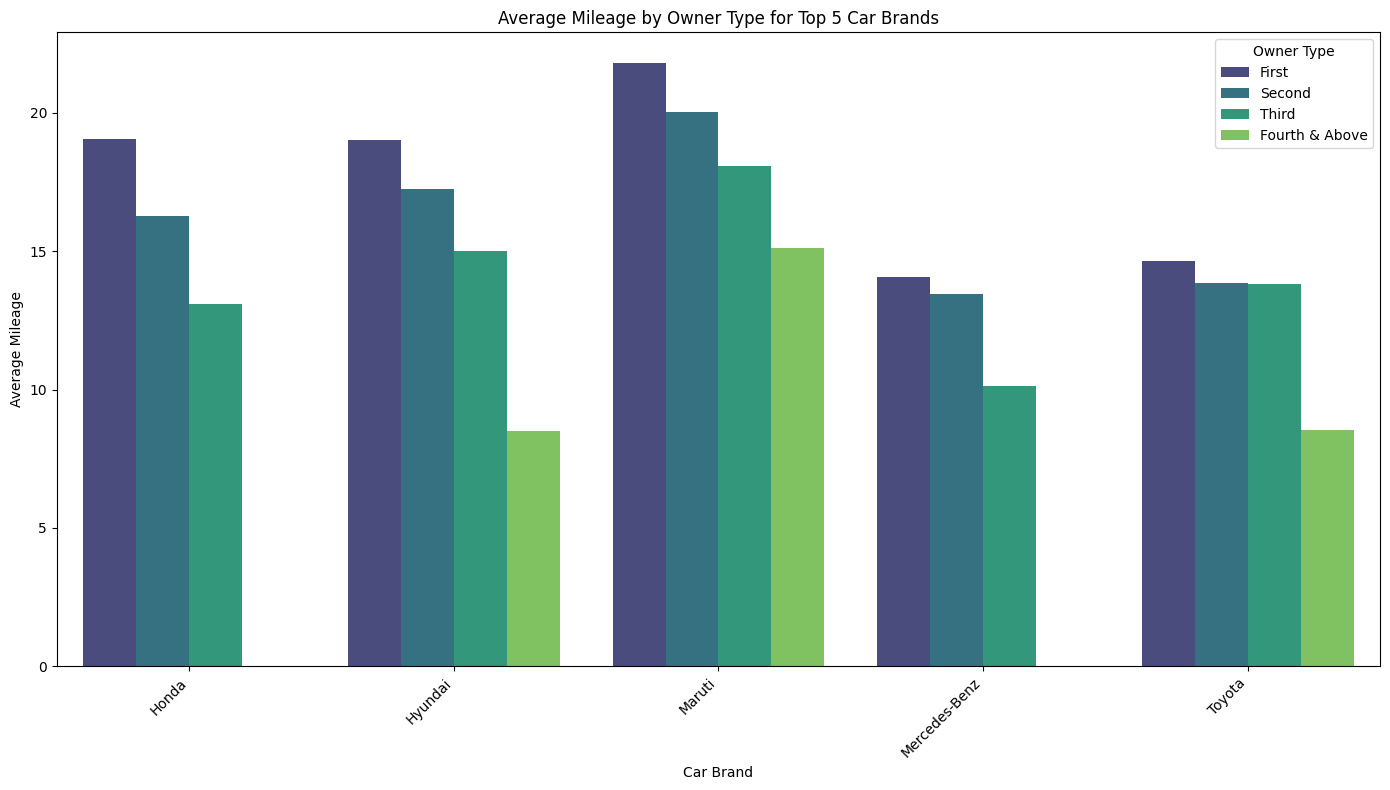

In [ ]:
plt.figure(figsize=(14, 8))
sns.barplot(x='Brand', y='Mileage', hue='Owner_Type', data=mileage_top_5_brands, palette='viridis')
plt.title('Average Mileage by Owner Type for Top 5 Car Brands')
plt.xlabel('Car Brand')
plt.ylabel('Average Mileage')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Owner Type')
plt.tight_layout()
plt.show()


To visualize the distribution of car prices, I will create two subplots: a histogram to show the frequency distribution and a box plot to illustrate the central tendency, spread, and outliers. This follows the instructions to understand car pricing characteristics.



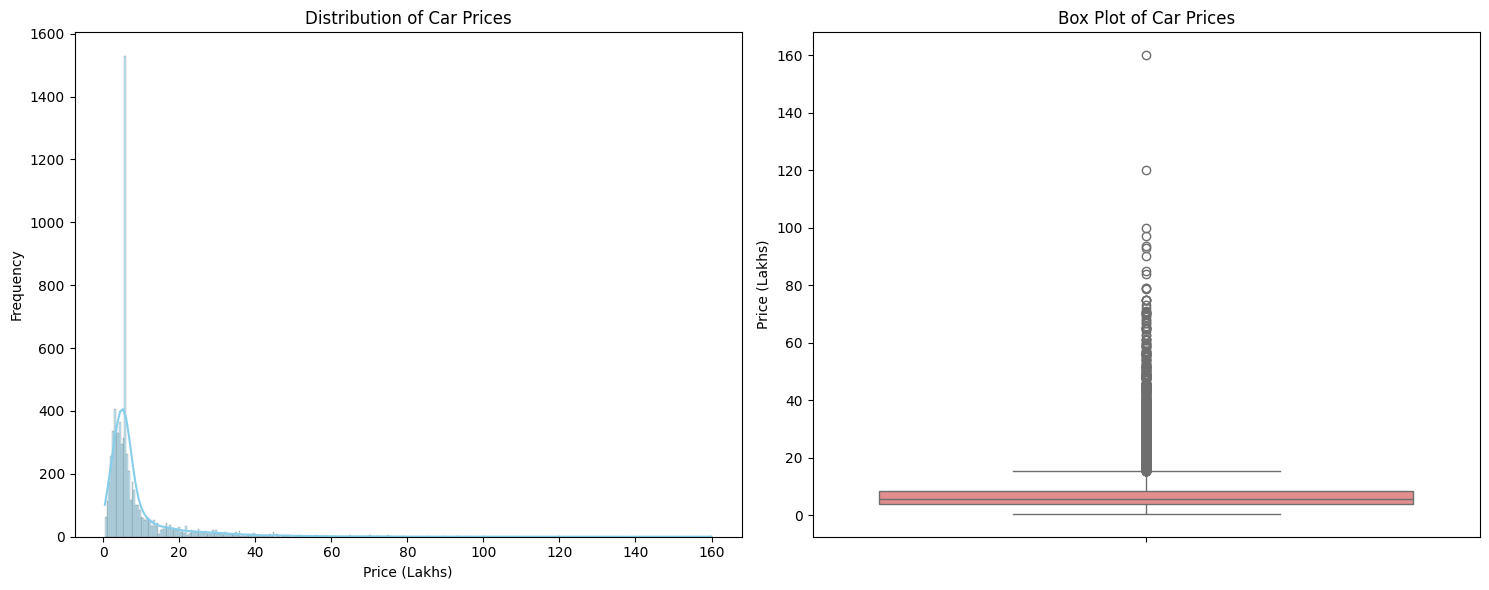

In [ ]:
plt.figure(figsize=(15, 6))

# Subplot 1: Histogram
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(df['Price'], kde=True, color='skyblue')
plt.title('Distribution of Car Prices')
plt.xlabel('Price (Lakhs)')
plt.ylabel('Frequency')

# Subplot 2: Box Plot
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(y=df['Price'], color='lightcoral')
plt.title('Box Plot of Car Prices')
plt.ylabel('Price (Lakhs)')

plt.tight_layout()
plt.show()

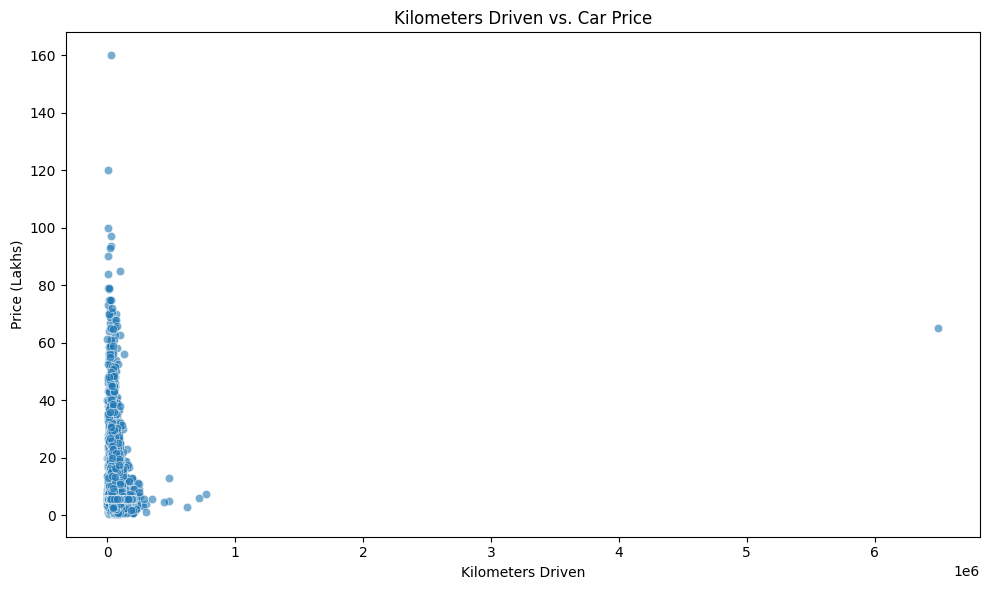

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Kilometers_Driven', y='Price', data=df, alpha=0.6)
plt.title('Kilometers Driven vs. Car Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Price (Lakhs)')
plt.tight_layout()
plt.show()

In [ ]:
top_10_brands = df['Brand'].value_counts().head(10).index.tolist()
average_price_by_brand = df[df['Brand'].isin(top_10_brands)].groupby('Brand')['Price'].mean().sort_values(ascending=False)

print("Average Price for Top 10 Car Brands:")
display(average_price_by_brand)

Average Price for Top 10 Car Brands:


,Price
Brand,
Mercedes-Benz,23.355842
BMW,22.415769
Audi,22.116702
Toyota,10.450751
Mahindra,7.600758
Ford,6.707863
Honda,5.453217
Hyundai,5.395000
Volkswagen,5.359759


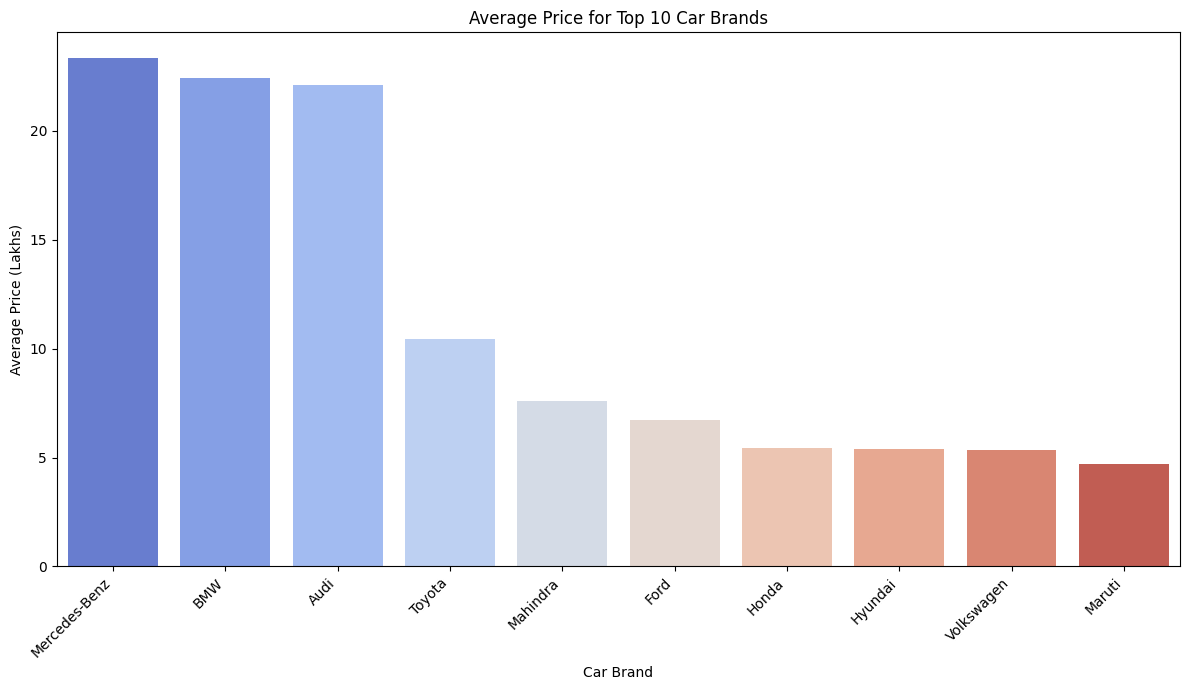

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x=average_price_by_brand.index, y=average_price_by_brand.values, palette='coolwarm', hue=average_price_by_brand.index, legend=False)
plt.title('Average Price for Top 10 Car Brands')
plt.xlabel('Car Brand')
plt.ylabel('Average Price (Lakhs)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Identify categorical columns to be encoded (excluding 'Location' and 'Brand')
categorical_cols = ['Fuel_Type', 'Transmission', 'Owner_Type']

print(f"Categorical columns identified for One-Hot Encoding: {categorical_cols}")

Categorical columns identified for One-Hot Encoding: ['Fuel_Type', 'Transmission', 'Owner_Type']


In [ ]:
# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True) # drop_first avoids multicollinearity

print("DataFrame after One-Hot Encoding:")
display(df_encoded.head())

DataFrame after One-Hot Encoding:


,S.No.,Name,Location,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price,Brand,Fuel_Type_Diesel,Fuel_Type_LPG,Fuel_Type_Petrol,Transmission_Manual,Owner_Type_Fourth & Above,Owner_Type_Second,Owner_Type_Third
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,26.60,998.0,58.16,5.0,1.75,Maruti,False,False,False,True,False,False,False
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,19.67,1582.0,126.20,5.0,12.50,Hyundai,True,False,False,True,False,False,False
2,2,Honda Jazz V,Chennai,2011,46000,18.20,1199.0,88.70,5.0,4.50,Honda,False,False,True,True,False,False,False
3,3,Maruti Ertiga VDI,Chennai,2012,87000,20.77,1248.0,88.76,7.0,6.00,Maruti,True,False,False,True,False,False,False
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,15.20,1968.0,140.80,5.0,17.74,Audi,True,False,False,False,False,True,False


In [ ]:
# Display the new shape of the DataFrame and check for any remaining object type columns
print(f"New shape of DataFrame: {df_encoded.shape}")
print("Remaining object columns:")
print(df_encoded.select_dtypes(include='object').columns)

New shape of DataFrame: (7251, 18)
Remaining object columns:
Index(['Name', 'Location', 'Brand'], dtype='object')


In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling
# Exclude 'S.No.' if it's just an identifier, and 'Price' if it's the target variable
# The remaining object columns ('Name', 'Location', 'Brand') are not scaled here
numerical_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['S.No.', 'Price']]

print(f"Numerical columns identified for scaling: {numerical_cols}")

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the identified numerical columns
df_scaled = df_encoded.copy() # Create a copy to avoid modifying the original encoded DataFrame directly
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

print("\nDataFrame after applying StandardScaler to numerical features:")
display(df_scaled.head())

Numerical columns identified for scaling: ['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats']

DataFrame after applying StandardScaler to numerical features:


,S.No.,Name,Location,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price,Brand,Fuel_Type_Diesel,Fuel_Type_LPG,Fuel_Type_Petrol,Transmission_Manual,Owner_Type_Fourth & Above,Owner_Type_Second,Owner_Type_Third
0,0,Maruti Wagon R LXI CNG,Mumbai,-1.034092,0.157494,1.854151,-1.043174,-1.033724,-0.343296,1.75,Maruti,False,False,False,True,False,False,False
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,0.502299,-0.209660,0.335041,-0.058606,0.253960,-0.343296,12.50,Hyundai,True,False,False,True,False,False,False
2,2,Honda Jazz V,Chennai,-0.726814,-0.150442,0.012806,-0.704307,-0.455742,-0.343296,4.50,Honda,False,False,True,True,False,False,False
3,3,Maruti Ertiga VDI,Chennai,-0.419536,0.335149,0.576170,-0.621698,-0.454607,2.128642,6.00,Maruti,True,False,False,True,False,False,False
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,-0.112258,-0.213568,-0.644817,0.592152,0.530271,-0.343296,17.74,Audi,True,False,False,False,False,True,False


In [ ]:
# Verify the mean and standard deviation of scaled columns
print("Mean of scaled numerical columns:")
print(df_scaled[numerical_cols].mean().round(2))
print("\nStandard deviation of scaled numerical columns:")
print(df_scaled[numerical_cols].std().round(2))

Mean of scaled numerical columns:
Year                 0.0
Kilometers_Driven    0.0
Mileage             -0.0
Engine               0.0
Power                0.0
Seats               -0.0
dtype: float64

Standard deviation of scaled numerical columns:
Year                 1.0
Kilometers_Driven    1.0
Mileage              1.0
Engine               1.0
Power                1.0
Seats                1.0
dtype: float64


In [ ]:
# Function to detect outliers using IQR method
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Function to cap outliers using IQR method
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# Numerical columns to check for outliers (excluding S.No. and Name, Location, Brand which are categorical)
numerical_cols_for_outliers = ['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']

print("Detecting and handling outliers using IQR method:")
for col in numerical_cols_for_outliers:
    outliers, lb, ub = detect_outliers_iqr(df_scaled, col)
    if not outliers.empty:
        print(f"\nColumn '{col}': {len(outliers)} outliers detected (min: {outliers[col].min():.2f}, max: {outliers[col].max():.2f})")
        print(f"  Bounds: Lower={lb:.2f}, Upper={ub:.2f}")
        df_scaled = cap_outliers_iqr(df_scaled, col)
        print(f"  Outliers in '{col}' capped.")
    else:
        print(f"\nColumn '{col}': No outliers detected.")

print("\nDataFrame head after outlier capping:")
display(df_scaled.head())

Detecting and handling outliers using IQR method:

Column 'Year': 58 outliers detected (min: -5.34, max: -3.19)
  Bounds: Lower=-3.03, Upper=3.11
  Outliers in 'Year' capped.

Column 'Kilometers_Driven': 258 outliers detected (min: 0.86, max: 76.29)
  Bounds: Lower=-0.99, Upper=0.86
  Outliers in 'Kilometers_Driven' capped.

Column 'Mileage': 99 outliers detected (min: -3.98, max: 3.38)
  Bounds: Lower=-2.60, Upper=2.60
  Outliers in 'Mileage' capped.

Column 'Engine': 65 outliers detected (min: 2.66, max: 7.39)
  Bounds: Lower=-2.65, Upper=2.54
  Outliers in 'Engine' capped.

Column 'Power': 274 outliers detected (min: 2.24, max: 9.52)
  Bounds: Lower=-2.39, Upper=2.20
  Outliers in 'Power' capped.

Column 'Seats': 1153 outliers detected (min: -6.52, max: 5.84)
  Bounds: Lower=-0.34, Upper=-0.34
  Outliers in 'Seats' capped.

Column 'Price': 982 outliers detected (min: 15.25, max: 160.00)
  Bounds: Lower=-2.98, Upper=15.23
  Outliers in 'Price' capped.

DataFrame head after outlier ca

,S.No.,Name,Location,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price,Brand,Fuel_Type_Diesel,Fuel_Type_LPG,Fuel_Type_Petrol,Transmission_Manual,Owner_Type_Fourth & Above,Owner_Type_Second,Owner_Type_Third
0,0,Maruti Wagon R LXI CNG,Mumbai,-1.034092,0.157494,1.854151,-1.043174,-1.033724,-0.343296,1.750,Maruti,False,False,False,True,False,False,False
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,0.502299,-0.209660,0.335041,-0.058606,0.253960,-0.343296,12.500,Hyundai,True,False,False,True,False,False,False
2,2,Honda Jazz V,Chennai,-0.726814,-0.150442,0.012806,-0.704307,-0.455742,-0.343296,4.500,Honda,False,False,True,True,False,False,False
3,3,Maruti Ertiga VDI,Chennai,-0.419536,0.335149,0.576170,-0.621698,-0.454607,-0.343296,6.000,Maruti,True,False,False,True,False,False,False
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,-0.112258,-0.213568,-0.644817,0.592152,0.530271,-0.343296,15.225,Audi,True,False,False,False,False,True,False


In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# The df_scaled DataFrame is assumed to be already created and preprocessed
# from previous cells that handled data loading, cleaning, one-hot encoding,
# standard scaling, and outlier capping. Therefore, redundant steps are removed.

# --- Apply Label Encoding to 'Location' column ---
le_location = LabelEncoder()
df_scaled['Location_Encoded'] = le_location.fit_transform(df_scaled['Location'])

print("\nDataFrame head with new 'Location_Encoded' column:")
display(df_scaled[['Location', 'Location_Encoded']].head())

print("\nUnique values in 'Location' and their encoded counterparts:")
location_mapping = dict(zip(le_location.classes_, le_location.transform(le_location.classes_)))
print(location_mapping)

# --- Apply Label Encoding to 'Brand' column ---
le_brand = LabelEncoder()
df_scaled['Brand_Encoded'] = le_brand.fit_transform(df_scaled['Brand'])

print("\nDataFrame head with new 'Brand_Encoded' column and 'Location_Encoded' column:")
display(df_scaled[['Brand', 'Brand_Encoded', 'Location', 'Location_Encoded']].head())

print("\nUnique values in 'Brand' and their encoded counterparts:")
brand_mapping = dict(zip(le_brand.classes_, le_brand.transform(le_brand.classes_)))
print(brand_mapping)


DataFrame head with new 'Location_Encoded' column:


,Location,Location_Encoded
0,Mumbai,9
1,Pune,10
2,Chennai,2
3,Chennai,2
4,Coimbatore,3



Unique values in 'Location' and their encoded counterparts:
{'Ahmedabad': np.int64(0), 'Bangalore': np.int64(1), 'Chennai': np.int64(2), 'Coimbatore': np.int64(3), 'Delhi': np.int64(4), 'Hyderabad': np.int64(5), 'Jaipur': np.int64(6), 'Kochi': np.int64(7), 'Kolkata': np.int64(8), 'Mumbai': np.int64(9), 'Pune': np.int64(10)}

DataFrame head with new 'Brand_Encoded' column and 'Location_Encoded' column:


,Brand,Brand_Encoded,Location,Location_Encoded
0,Maruti,18,Mumbai,9
1,Hyundai,11,Pune,10
2,Honda,10,Chennai,2
3,Maruti,18,Chennai,2
4,Audi,1,Coimbatore,3



Unique values in 'Brand' and their encoded counterparts:
{'Ambassador': np.int64(0), 'Audi': np.int64(1), 'BMW': np.int64(2), 'Bentley': np.int64(3), 'Chevrolet': np.int64(4), 'Datsun': np.int64(5), 'Fiat': np.int64(6), 'Force': np.int64(7), 'Ford': np.int64(8), 'Hindustan': np.int64(9), 'Honda': np.int64(10), 'Hyundai': np.int64(11), 'Isuzu': np.int64(12), 'Jaguar': np.int64(13), 'Jeep': np.int64(14), 'Lamborghini': np.int64(15), 'Land': np.int64(16), 'Mahindra': np.int64(17), 'Maruti': np.int64(18), 'Mercedes-Benz': np.int64(19), 'Mini': np.int64(20), 'Mitsubishi': np.int64(21), 'Nissan': np.int64(22), 'OpelCorsa': np.int64(23), 'Porsche': np.int64(24), 'Renault': np.int64(25), 'Skoda': np.int64(26), 'Smart': np.int64(27), 'Tata': np.int64(28), 'Toyota': np.int64(29), 'Volkswagen': np.int64(30), 'Volvo': np.int64(31)}


In [ ]:
print("Descriptive statistics after outlier capping:")
display(df_scaled[numerical_cols_for_outliers].describe())

Descriptive statistics after outlier capping:


,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,7251.000000,7251.000000,7251.000000,7251.000000,7251.000000,7.251000e+03,7251.000000
mean,0.004789,-0.028690,0.013934,-0.012754,-0.036688,-3.432963e-01,6.841949
std,0.982955,0.357572,0.943645,0.949821,0.866792,2.242805e-14,4.213960
min,-3.031401,-0.693225,-2.601247,-1.673702,-1.487177,-3.432963e-01,0.440000
25%,-0.726814,-0.292566,-0.651394,-0.705993,-0.667707,-3.432963e-01,3.850000
50%,0.195021,-0.062301,0.004038,-0.208652,-0.268381,-3.432963e-01,5.640000
75%,0.809577,0.169337,0.648509,0.592152,0.477848,-3.432963e-01,8.400000
max,1.731412,0.862192,2.598362,2.539370,2.196180,-3.432963e-01,15.225000


In [ ]:
df_scaled

,S.No.,Name,Location,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price,Brand,Fuel_Type_Diesel,Fuel_Type_LPG,Fuel_Type_Petrol,Transmission_Manual,Owner_Type_Fourth & Above,Owner_Type_Second,Owner_Type_Third,Location_Encoded,Brand_Encoded
0,0,Maruti Wagon R LXI CNG,Mumbai,-1.034092,0.157494,1.854151,-1.043174,-1.033724,-0.343296,1.750,Maruti,False,False,False,True,False,False,False,9,18
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,0.502299,-0.209660,0.335041,-0.058606,0.253960,-0.343296,12.500,Hyundai,True,False,False,True,False,False,False,10,11
2,2,Honda Jazz V,Chennai,-0.726814,-0.150442,0.012806,-0.704307,-0.455742,-0.343296,4.500,Honda,False,False,True,True,False,False,False,2,10
3,3,Maruti Ertiga VDI,Chennai,-0.419536,0.335149,0.576170,-0.621698,-0.454607,-0.343296,6.000,Maruti,True,False,False,True,False,False,False,2,18
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,-0.112258,-0.213568,-0.644817,0.592152,0.530271,-0.343296,15.225,Audi,True,False,False,False,False,True,False,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7248,7248,Volkswagen Vento Diesel Trendline,Hyderabad,-0.726814,0.363704,0.525752,-0.031632,-0.173754,-0.343296,5.640,Volkswagen,True,False,False,True,False,False,False,5,30
7249,7249,Volkswagen Polo GT TSI,Mumbai,0.502299,0.003526,-0.204210,-0.707679,-0.173754,-0.343296,5.640,Volkswagen,False,False,True,False,False,False,False,9,30
7250,7250,Nissan Micra Diesel XV,Kolkata,-0.419536,-0.363628,1.082540,-0.262601,-0.940232,-0.343296,5.640,Nissan,True,False,False,True,False,False,False,8,22
7251,7251,Volkswagen Polo GT TSI,Pune,-0.112258,-0.076277,-0.206402,-0.707679,-0.173754,-0.343296,5.640,Volkswagen,False,False,True,False,False,False,True,10,30


# Task
Drop the 'Name', 'Location', and 'Brand' columns from the `df_scaled` DataFrame, then display the first few rows of the modified DataFrame to confirm the changes.

## Drop Original Categorical Columns

### Subtask:
Remove the original 'Name', 'Location', and 'Brand' columns from `df_scaled` as their encoded versions (`Location_Encoded` and `Brand_Encoded`) are now available, and 'Name' is generally not used directly in ML models.


**Reasoning**:
To remove the specified columns from the DataFrame, I will use the `drop` method and then display the head to verify the changes.



In [ ]:
df_scaled.drop(['Name', 'Location', 'Brand'], axis=1, inplace=True)
print("DataFrame after dropping 'Name', 'Location', and 'Brand' columns:")
display(df_scaled.head())

DataFrame after dropping 'Name', 'Location', and 'Brand' columns:


,S.No.,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price,Fuel_Type_Diesel,Fuel_Type_LPG,Fuel_Type_Petrol,Transmission_Manual,Owner_Type_Fourth & Above,Owner_Type_Second,Owner_Type_Third,Location_Encoded,Brand_Encoded
0,0,-1.034092,0.157494,1.854151,-1.043174,-1.033724,-0.343296,1.750,False,False,False,True,False,False,False,9,18
1,1,0.502299,-0.209660,0.335041,-0.058606,0.253960,-0.343296,12.500,True,False,False,True,False,False,False,10,11
2,2,-0.726814,-0.150442,0.012806,-0.704307,-0.455742,-0.343296,4.500,False,False,True,True,False,False,False,2,10
3,3,-0.419536,0.335149,0.576170,-0.621698,-0.454607,-0.343296,6.000,True,False,False,True,False,False,False,2,18
4,4,-0.112258,-0.213568,-0.644817,0.592152,0.530271,-0.343296,15.225,True,False,False,False,False,True,False,3,1


## Final Task

### Subtask:
Confirm that the specified columns have been dropped and the DataFrame is ready for further machine learning preparation.


## Summary:

### Q&A
The specified columns ('Name', 'Location', and 'Brand') have been successfully dropped from the `df_scaled` DataFrame, making it ready for further machine learning preparation.

### Data Analysis Key Findings
*   The 'Name', 'Location', and 'Brand' columns were successfully removed from the `df_scaled` DataFrame.
*   The modified `df_scaled` DataFrame now includes scaled numerical features, one-hot encoded `Fuel_Type` and `Owner_Type` columns, `Location_Encoded`, `Brand_Encoded`, `S.No.`, and `Price`.

### Insights or Next Steps
*   The `df_scaled` DataFrame is now prepared with relevant numerical and encoded categorical features, suitable for direct input into machine learning models.
*   The next logical step would be to perform feature selection (if necessary), split the data into training and testing sets, and begin model training and evaluation.


In [ ]:
# Drop the 'S.No.' column if it exists
if 'S.No.' in df_scaled.columns:
    df_scaled = df_scaled.drop('S.No.', axis=1)
    print("DataFrame after dropping 'S.No.' column.")
else:
    print("'S.No.' column not found, assuming it was already dropped.")

# Convert boolean columns to int (0/1)
# Identify boolean columns
boolean_cols = df_scaled.select_dtypes(include='bool').columns

# Convert boolean columns to int (True -> 1, False -> 0)
if not boolean_cols.empty:
    df_scaled[boolean_cols] = df_scaled[boolean_cols].astype(int)
    print("\nDataFrame after converting boolean columns to 0/1:")
else:
    print("\nNo boolean columns found to convert.")

display(df_scaled.head())

print("\nUpdated DataFrame Info (check dtypes for numerical columns):")
df_scaled.info()

DataFrame after dropping 'S.No.' column.

DataFrame after converting boolean columns to 0/1:


,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price,Fuel_Type_Diesel,Fuel_Type_LPG,Fuel_Type_Petrol,Transmission_Manual,Owner_Type_Fourth & Above,Owner_Type_Second,Owner_Type_Third,Location_Encoded,Brand_Encoded
0,-1.034092,0.157494,1.854151,-1.043174,-1.033724,-0.343296,1.750,0,0,0,1,0,0,0,9,18
1,0.502299,-0.209660,0.335041,-0.058606,0.253960,-0.343296,12.500,1,0,0,1,0,0,0,10,11
2,-0.726814,-0.150442,0.012806,-0.704307,-0.455742,-0.343296,4.500,0,0,1,1,0,0,0,2,10
3,-0.419536,0.335149,0.576170,-0.621698,-0.454607,-0.343296,6.000,1,0,0,1,0,0,0,2,18
4,-0.112258,-0.213568,-0.644817,0.592152,0.530271,-0.343296,15.225,1,0,0,0,0,1,0,3,1



Updated DataFrame Info (check dtypes for numerical columns):
<class 'pandas.core.frame.DataFrame'>
Index: 7251 entries, 0 to 7252
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year                       7251 non-null   float64
 1   Kilometers_Driven          7251 non-null   float64
 2   Mileage                    7251 non-null   float64
 3   Engine                     7251 non-null   float64
 4   Power                      7251 non-null   float64
 5   Seats                      7251 non-null   float64
 6   Price                      7251 non-null   float64
 7   Fuel_Type_Diesel           7251 non-null   int64  
 8   Fuel_Type_LPG              7251 non-null   int64  
 9   Fuel_Type_Petrol           7251 non-null   int64  
 10  Transmission_Manual        7251 non-null   int64  
 11  Owner_Type_Fourth & Above  7251 non-null   int64  
 12  Owner_Type_Second          7251 non-null   int6

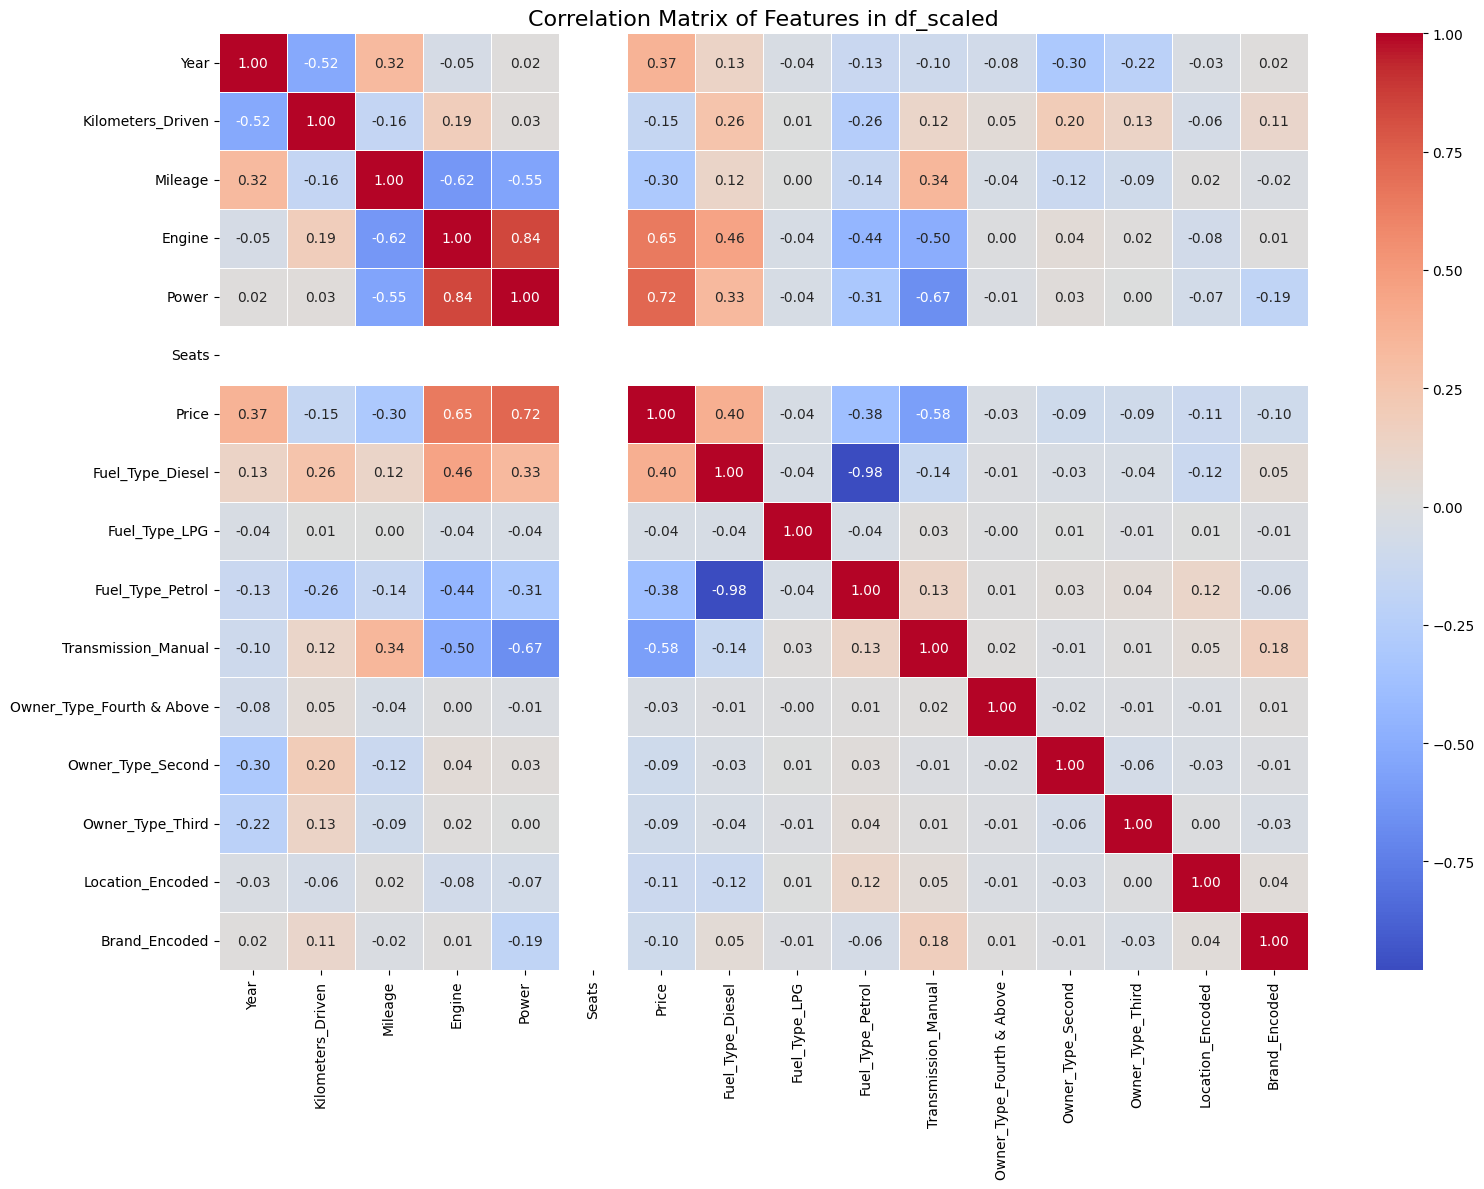

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df_scaled.corr()

# Set up the matplotlib figure
plt.figure(figsize=(16, 12))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features in df_scaled', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA

# Select the columns for PCA
pca_columns = ['Power', 'Engine', 'Price', 'Mileage']
X_pca = df_scaled[pca_columns]

# Initialize PCA with 1 component as requested
n_components = 1
pca = PCA(n_components=n_components)

# Fit PCA on the selected data and transform it
X_pca_transformed = pca.fit_transform(X_pca)

# Create a DataFrame for the transformed components
df_pca = pd.DataFrame(data=X_pca_transformed, columns=[f'PC_{i+1}' for i in range(n_components)])

print(f"Explained variance ratio for {n_components} principal component:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC_{i+1}: {ratio:.4f}")

print("\nCumulative explained variance:", pca.explained_variance_ratio_.sum().round(4))

print("\nFirst 5 rows of PCA transformed data (single component):")
display(df_pca.head())

Explained variance ratio for 1 principal component:
PC_1: 0.9192

Cumulative explained variance: 0.9192

First 5 rows of PCA transformed data (single component):


,PC_1
0,-5.403955
1,5.524392
2,-2.448627
3,-1.017173
4,8.392011


In [ ]:
# Reset index of df_scaled if it was modified in previous steps and doesn't align with df_pca
df_scaled = df_scaled.reset_index(drop=True)

# Append the PCA column to df_scaled
df_scaled = pd.concat([df_scaled, df_pca], axis=1)

# Drop the original columns used for PCA
columns_to_drop = ['Power', 'Engine', 'Price', 'Mileage']
df_scaled = df_scaled.drop(columns=columns_to_drop)

print("DataFrame head after appending PCA component and dropping original columns:")
display(df_scaled.head())

print("\nUpdated DataFrame Info:")
df_scaled.info()

DataFrame head after appending PCA component and dropping original columns:


,Year,Kilometers_Driven,Seats,Fuel_Type_Diesel,Fuel_Type_LPG,Fuel_Type_Petrol,Transmission_Manual,Owner_Type_Fourth & Above,Owner_Type_Second,Owner_Type_Third,Location_Encoded,Brand_Encoded,PC_1
0,-1.034092,0.157494,-0.343296,0,0,0,1,0,0,0,9,18,-5.403955
1,0.502299,-0.209660,-0.343296,1,0,0,1,0,0,0,10,11,5.524392
2,-0.726814,-0.150442,-0.343296,0,0,1,1,0,0,0,2,10,-2.448627
3,-0.419536,0.335149,-0.343296,1,0,0,1,0,0,0,2,18,-1.017173
4,-0.112258,-0.213568,-0.343296,1,0,0,0,0,1,0,3,1,8.392011



Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7251 entries, 0 to 7250
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year                       7251 non-null   float64
 1   Kilometers_Driven          7251 non-null   float64
 2   Seats                      7251 non-null   float64
 3   Fuel_Type_Diesel           7251 non-null   int64  
 4   Fuel_Type_LPG              7251 non-null   int64  
 5   Fuel_Type_Petrol           7251 non-null   int64  
 6   Transmission_Manual        7251 non-null   int64  
 7   Owner_Type_Fourth & Above  7251 non-null   int64  
 8   Owner_Type_Second          7251 non-null   int64  
 9   Owner_Type_Third           7251 non-null   int64  
 10  Location_Encoded           7251 non-null   int64  
 11  Brand_Encoded              7251 non-null   int64  
 12  PC_1                       7251 non-null   float64
dtypes: float64(4), int64(9)

In [ ]:
from scipy import stats

# Separate the PC_1 values into two groups based on Transmission_Manual
pc1_manual = df_scaled[df_scaled['Transmission_Manual'] == 1]['PC_1']
pc1_automatic = df_scaled[df_scaled['Transmission_Manual'] == 0]['PC_1']

# Perform independent two-sample t-test
t_statistic, p_value = stats.ttest_ind(pc1_manual, pc1_automatic, equal_var=False) # Assuming unequal variances

print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05 # Significance level
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.3f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("There is a statistically significant difference in the average PC_1 between manual and automatic transmission cars.")
else:
    print(f"\nSince the p-value ({p_value:.3f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in the average PC_1 between manual and automatic transmission cars.")

T-statistic: -52.103
P-value: 0.000

Since the p-value (0.000) is less than the significance level (0.05), we reject the null hypothesis.
There is a statistically significant difference in the average PC_1 between manual and automatic transmission cars.


### Z-Test

A **z-test** is very similar to a t-test and is also used to compare means. The main difference is that a z-test is typically used when:

*   The population standard deviation is known (which is rarely the case in real-world scenarios).
*   The sample size is very large (generally N > 30), allowing the sample standard deviation to be a good estimate of the population standard deviation.

For large datasets like ours, the t-distribution approaches the z-distribution, so a t-test is often robust enough even with a large sample size. If you *knew* the population standard deviation, you could replace `stats.ttest_ind` with a custom z-test calculation or a library function if available (Scipy primarily provides `zscore` for converting data to z-scores, but not a direct `ztest` function like `ttest_ind`).

**Example Use Case:** You could compare the average `Kilometers_Driven` of a sample to a known national average (population mean) if you also knew the national standard deviation for kilometers driven.

In [ ]:
from scipy.stats import f_oneway

# Get unique locations
unique_locations = df_scaled['Location_Encoded'].unique()

# Create a list of PC_1 values for each location group
groups = [df_scaled['PC_1'][df_scaled['Location_Encoded'] == loc] for loc in unique_locations]

# Perform one-way ANOVA
f_statistic, p_value = f_oneway(*groups)

print(f"F-statistic: {f_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05 # Significance level
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.3f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("There is a statistically significant difference in the average PC_1 across different locations.")
else:
    print(f"\nSince the p-value ({p_value:.3f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in the average PC_1 across different locations.")


F-statistic: 54.050
P-value: 0.000

Since the p-value (0.000) is less than the significance level (0.05), we reject the null hypothesis.
There is a statistically significant difference in the average PC_1 across different locations.


In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

# Create a contingency table
contingency_table = pd.crosstab(df_scaled['Transmission_Manual'], df_scaled['Fuel_Type_Diesel'])
print("Contingency Table:")
display(contingency_table)

# Perform the Chi-Square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"Degrees of freedom: {dof}")

# Interpret the results
alpha = 0.05 # Significance level
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.3f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("There is a statistically significant association between transmission type and fuel type (Diesel vs. Non-Diesel).")
else:
    print(f"\nSince the p-value ({p_value:.3f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant association between transmission type and fuel type (Diesel vs. Non-Diesel).")

Contingency Table:


Fuel_Type_Diesel,0,1
Transmission_Manual,,
0,730,1317
1,2669,2535



Chi-square statistic: 143.414
P-value: 0.000
Degrees of freedom: 1

Since the p-value (0.000) is less than the significance level (0.05), we reject the null hypothesis.
There is a statistically significant association between transmission type and fuel type (Diesel vs. Non-Diesel).


In [ ]:
from scipy.stats import mannwhitneyu

# Separate the PC_1 values into two groups based on Transmission_Manual
pc1_manual = df_scaled[df_scaled['Transmission_Manual'] == 1]['PC_1']
pc1_automatic = df_scaled[df_scaled['Transmission_Manual'] == 0]['PC_1']

# Perform Mann-Whitney U test
u_statistic, p_value = mannwhitneyu(pc1_manual, pc1_automatic, alternative='two-sided')

print(f"Mann-Whitney U statistic: {u_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05 # Significance level
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.3f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("There is a statistically significant difference in the median PC_1 between manual and automatic transmission cars.")
else:
    print(f"\nSince the p-value ({p_value:.3f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in the median PC_1 between manual and automatic transmission cars.")

Mann-Whitney U statistic: 1686152.000
P-value: 0.000

Since the p-value (0.000) is less than the significance level (0.05), we reject the null hypothesis.
There is a statistically significant difference in the median PC_1 between manual and automatic transmission cars.


In [ ]:
import plotly.express as px

# Ensure Year is treated as a discrete variable for animation frames
df_scaled['Year_str'] = df_scaled['Year'].round(0).astype(int).astype(str)

In [ ]:
# To fix the ValueError, we need to use a non-negative column for 'size'.
# The 'Seats' column in df_scaled was scaled and capped, resulting in negative values.
# We will use the original 'Seats' values from the 'df' DataFrame for size.
# Ensure df's index aligns with df_scaled's RangeIndex after dropping rows and resetting index.
df_scaled['Original_Seats'] = df['Seats'].reset_index(drop=True)

# Create the animated scatter plot
fig = px.scatter(
    df_scaled,
    x='Kilometers_Driven',
    y='PC_1',
    animation_frame='Year_str',
    animation_group='Brand_Encoded',
    size='Original_Seats', # Use the original, positive 'Seats' values for size
    color='Fuel_Type_Diesel', # Use 'Fuel_Type_Diesel' for color
    hover_name='Brand_Encoded',
    log_x=False, # Kilometers_Driven is already scaled, so log_x might not be ideal here
    size_max=20, # Max size of bubbles
    range_x=[df_scaled['Kilometers_Driven'].min(), df_scaled['Kilometers_Driven'].max()],
    range_y=[df_scaled['PC_1'].min(), df_scaled['PC_1'].max()],
    title='Animated Relationship between Kilometers Driven and PC_1 over Years'
)

# Update layout for better appearance
fig.update_layout(
    xaxis_title='Scaled Kilometers Driven',
    yaxis_title='PC_1 (Power, Engine, Price, Mileage Component)',
    width=900, # Set width for better display in Colab
    height=600
)

# Ensure the animation plays smoothly by setting frame duration
fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 500

fig.show()

### Interpretation of the Animated Scatter Plot:

This animated scatter plot visualizes the relationship between `Kilometers_Driven` (scaled) and `PC_1` (the principal component representing 'Power', 'Engine', 'Price', and 'Mileage') over the years.

*   **X-axis:** Scaled Kilometers Driven
*   **Y-axis:** PC_1 (representing combined car characteristics)
*   **Animation Frame:** `Year` (showing how the distribution changes year by year)
*   **Size of points:** `Seats` (indicating the number of seats in the car)
*   **Color of points:** `Fuel_Type_Diesel` (distinguishing between diesel and non-diesel cars)
*   **Hover Information:** Hover over points to see the `Brand_Encoded` value.

By playing the animation, you can observe:
*   How the distribution of cars across `Kilometers_Driven` and `PC_1` changes from year to year.
*   Whether newer cars tend to have different `PC_1` values or `Kilometers_Driven` patterns compared to older ones.
*   Any clusters or trends that emerge over time, for instance, if certain car types (by fuel or number of seats) become more prevalent or shift in their performance characteristics.

In [ ]:
import plotly.express as px

fig_3d = px.scatter_3d(
    df_scaled,
    x='Kilometers_Driven',
    y='Year',
    z='PC_1',
    color='PC_1', # Color points based on PC_1 values
    size='Original_Seats', # Use Original_Seats for size
    hover_data={ # Include additional data on hover
        'Kilometers_Driven': ':.2f',
        'Year': ':.0f',
        'PC_1': ':.2f',
        'Original_Seats': True,
        'Brand_Encoded': True,
        'Location_Encoded': True,
        'Fuel_Type_Diesel': True,
        'Transmission_Manual': True
    },
    title='3D Scatter Plot: Kilometers Driven vs. Year vs. PC_1',
    labels={
        'Kilometers_Driven': 'Scaled Kilometers Driven',
        'Year': 'Scaled Year',
        'PC_1': 'PC_1 (Power, Engine, Price, Mileage)'
    }
)

fig_3d.update_layout(scene = dict(
    xaxis_title='Scaled Kilometers Driven',
    yaxis_title='Scaled Year',
    zaxis_title='PC_1 (Combined Car Characteristics)'
))

fig_3d.show()

Generating Pair Plot...


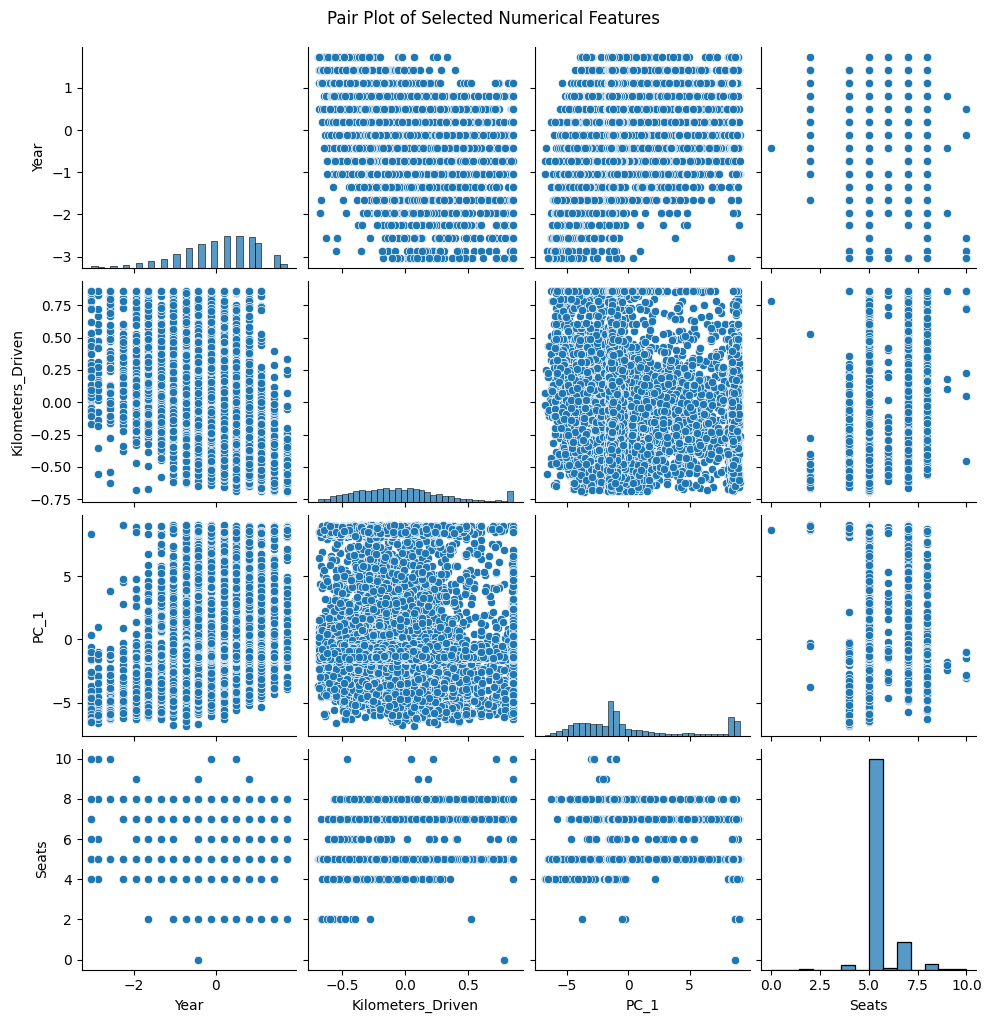


Generating Violin Plot...


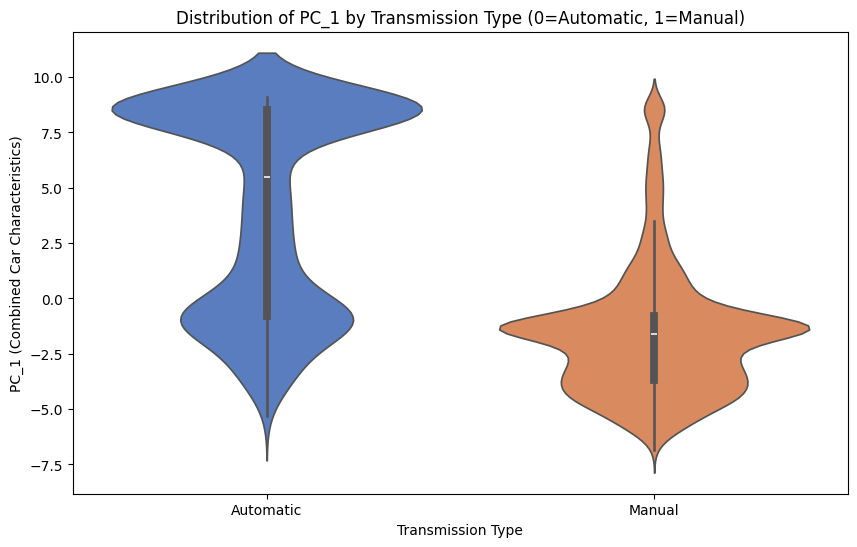


Generating KDE Plot for PC_1...


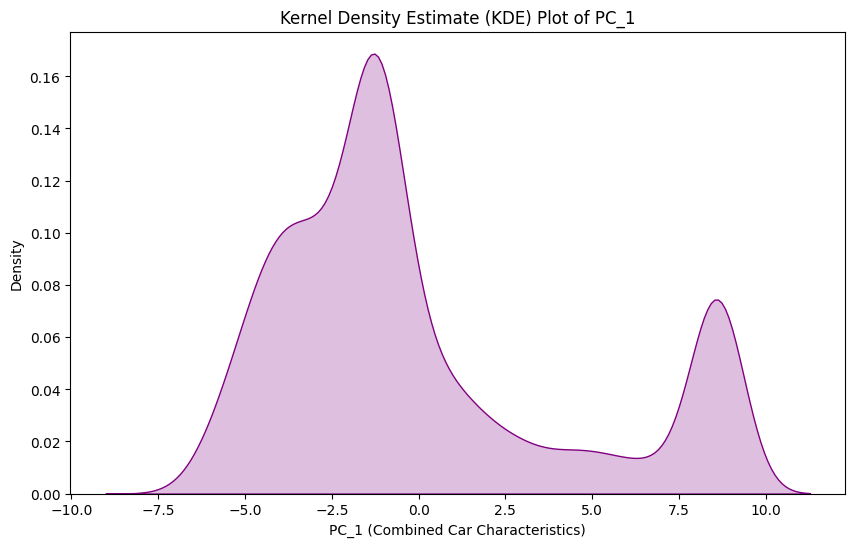

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Pair Plot ---
# Selecting a subset of numerical columns for the pair plot to keep it manageable
# using the 'Original_Seats' for better interpretability in this visualization
# We will temporarily add it back for this specific plot
df_for_pairplot = df_scaled[['Year', 'Kilometers_Driven', 'PC_1', 'Original_Seats']].copy()
df_for_pairplot.rename(columns={'Original_Seats': 'Seats'}, inplace=True)

print("Generating Pair Plot...")
sns.pairplot(df_for_pairplot)
plt.suptitle('Pair Plot of Selected Numerical Features', y=1.02) # Adjust suptitle position
plt.show()

# --- 2. Violin Plot ---
# Visualizing the distribution of PC_1 across different transmission types
print("\nGenerating Violin Plot...")
plt.figure(figsize=(10, 6))
sns.violinplot(x='Transmission_Manual', y='PC_1', hue='Transmission_Manual', data=df_scaled, palette='muted', legend=False)
plt.title('Distribution of PC_1 by Transmission Type (0=Automatic, 1=Manual)')
plt.xlabel('Transmission Type')
plt.ylabel('PC_1 (Combined Car Characteristics)')
plt.xticks(ticks=[0, 1], labels=['Automatic', 'Manual'])
plt.show()

# --- 3. KDE Plot (Kernel Density Estimate) ---
# Visualizing the distribution of PC_1
print("\nGenerating KDE Plot for PC_1...")
plt.figure(figsize=(10, 6))
sns.kdeplot(df_scaled['PC_1'], fill=True, color='purple')
plt.title('Kernel Density Estimate (KDE) Plot of PC_1')
plt.xlabel('PC_1 (Combined Car Characteristics)')
plt.ylabel('Density')
plt.show()

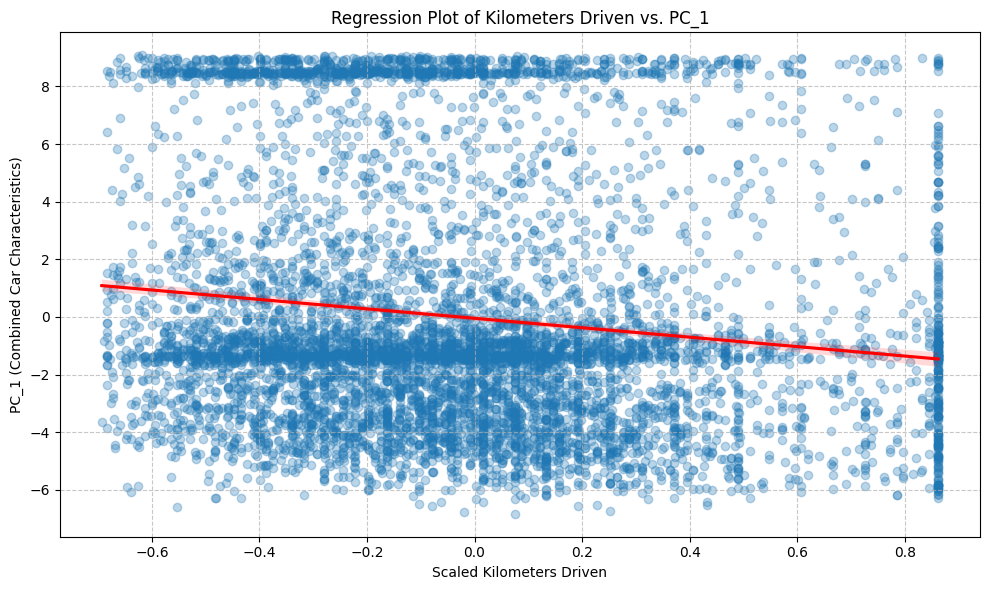

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(x='Kilometers_Driven', y='PC_1', data=df_scaled, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Regression Plot of Kilometers Driven vs. PC_1')
plt.xlabel('Scaled Kilometers Driven')
plt.ylabel('PC_1 (Combined Car Characteristics)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Group by 'Location_Encoded' and calculate the mean of 'PC_1'
avg_pc1_by_location = df_scaled.groupby('Location_Encoded')['PC_1'].mean().reset_index()

print("Average PC_1 by Encoded Location:")
display(avg_pc1_by_location)

Average PC_1 by Encoded Location:


,Location_Encoded,PC_1
0,0,0.045583
1,1,1.360249
2,2,-0.832006
3,3,1.982061
4,4,0.242708
5,5,0.144533
6,6,-1.601201
7,7,0.899078
8,8,-1.812430
9,9,0.232271


In [ ]:
import pandas as pd

# Recalculate the correlation matrix with the updated df_scaled DataFrame
# df_scaled now contains 'PC_1' and no longer contains the individual components (Power, Engine, Price, Mileage)
correlation_matrix = df_scaled.corr()

# Calculate absolute correlations of all features with 'PC_1'
# Exclude PC_1 itself from the correlation calculation as it will have a correlation of 1 with itself
correlations_with_pc1 = correlation_matrix['PC_1'].drop('PC_1').abs().sort_values(ascending=False)

print("Absolute Correlations with PC_1 (Sorted Descending):")
display(correlations_with_pc1)


Absolute Correlations with PC_1 (Sorted Descending):


,PC_1
Transmission_Manual,0.596806
Fuel_Type_Diesel,0.399033
Fuel_Type_Petrol,0.382997
Year,0.346522
Year_str,0.332117
Original_Seats,0.184881
Kilometers_Driven,0.135500
Location_Encoded,0.114254
Brand_Encoded,0.098206
Owner_Type_Third,0.083483


In [ ]:
# Assuming 'df' (original DataFrame) is available from previous steps
# And 'df_scaled' is the current working DataFrame

# 1. Get original 'Year' from the 'df' DataFrame (before scaling and outlier capping)
# Use .copy() to ensure we are working with a separate Series
original_years = df['Year'].reset_index(drop=True).copy()

# 2. Calculate 'Age' based on a reference year (e.g., the year after the latest car in the dataset)
# The max year in the original dataset is 2019. Let's use 2020 as 'current_year' for age calculation.
current_year_reference = 2020
new_age = current_year_reference - original_years

# 3. Scale the new 'Age' feature using StandardScaler
# It's important to scale it, as other numerical features are scaled.
from sklearn.preprocessing import StandardScaler

# Create a new StandardScaler instance for the Age feature
age_scaler = StandardScaler()

# Fit and transform the 'Age' feature (needs to be 2D array, so reshape)
df_scaled['Age'] = age_scaler.fit_transform(new_age.values.reshape(-1, 1))

# 4. Drop the original 'Year' column as 'Age' now represents this information more directly
df_scaled = df_scaled.drop('Year', axis=1)

print("DataFrame head after adding scaled 'Age' feature and dropping 'Year':")
display(df_scaled.head())

print("\nUpdated DataFrame Info:")
df_scaled.info()

DataFrame head after adding scaled 'Age' feature and dropping 'Year':


,Kilometers_Driven,Seats,Fuel_Type_Diesel,Fuel_Type_LPG,Fuel_Type_Petrol,Transmission_Manual,Owner_Type_Fourth & Above,Owner_Type_Second,Owner_Type_Third,Location_Encoded,Brand_Encoded,PC_1,Year_str,Original_Seats,Age
0,0.157494,-0.343296,0,0,0,1,0,0,0,9,18,-5.403955,-1,5.0,1.034092
1,-0.209660,-0.343296,1,0,0,1,0,0,0,10,11,5.524392,1,5.0,-0.502299
2,-0.150442,-0.343296,0,0,1,1,0,0,0,2,10,-2.448627,-1,5.0,0.726814
3,0.335149,-0.343296,1,0,0,1,0,0,0,2,18,-1.017173,0,7.0,0.419536
4,-0.213568,-0.343296,1,0,0,0,0,1,0,3,1,8.392011,0,5.0,0.112258



Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7251 entries, 0 to 7250
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Kilometers_Driven          7251 non-null   float64
 1   Seats                      7251 non-null   float64
 2   Fuel_Type_Diesel           7251 non-null   int64  
 3   Fuel_Type_LPG              7251 non-null   int64  
 4   Fuel_Type_Petrol           7251 non-null   int64  
 5   Transmission_Manual        7251 non-null   int64  
 6   Owner_Type_Fourth & Above  7251 non-null   int64  
 7   Owner_Type_Second          7251 non-null   int64  
 8   Owner_Type_Third           7251 non-null   int64  
 9   Location_Encoded           7251 non-null   int64  
 10  Brand_Encoded              7251 non-null   int64  
 11  PC_1                       7251 non-null   float64
 12  Year_str                   7251 non-null   object 
 13  Original_Seats         

### Interpretation of the New 'Age' Feature:

By creating and scaling the 'Age' feature, we have introduced a direct measure of how old each car is. This is often a more intuitive and impactful feature for car valuation models compared to just the manufacturing year, as car depreciation is strongly linked to age.

*   The 'Age' feature is now scaled, similar to other numerical features in the `df_scaled` DataFrame.
*   The original 'Year' column has been removed to avoid multicollinearity, as 'Age' is a direct (inverse) linear transformation of 'Year'.

This step concludes the primary feature engineering tasks, preparing the dataset for model training.

### Interpretation of Feature Correlations with PC_1:

The output above displays the absolute correlation of each feature with `PC_1`, sorted in descending order. `PC_1` is our principal component representing a combination of 'Power', 'Engine', 'Price', and 'Mileage'.

*   **High Correlation:** Features with higher absolute correlation values are more strongly related to `PC_1`. This indicates that these features explain a significant amount of variance in the combined car characteristics represented by `PC_1`.
*   **Low Correlation:** Features with lower absolute correlation values have a weaker linear relationship with `PC_1`.

### Next Steps for Feature Selection:

Based on these correlations, we can decide which features to keep for building a predictive model (e.g., predicting `PC_1`). Common strategies include:

1.  **Thresholding:** Selecting features whose absolute correlation with `PC_1` is above a certain threshold (e.g., 0.1 or 0.2).
2.  **Top N Features:** Choosing the top N most correlated features.
3.  **Domain Knowledge:** Combining statistical insights with domain expertise to make informed decisions about feature inclusion.

This step helps in reducing dimensionality and potentially improving model performance by focusing on the most informative features.

In [ ]:
import plotly.express as px
import pandas as pd

# Calculate car distribution by Location_Encoded
location_counts_encoded = df_scaled['Location_Encoded'].value_counts().reset_index()
location_counts_encoded.columns = ['Location_Encoded', 'Car_Count']

# Create a mapping from encoded value to original location name using the existing 'location_mapping'
# We need to reverse the mapping to get location name from encoded integer
reverse_location_mapping = {v: k for k, v in location_mapping.items()}

# Map the encoded locations back to their original names
location_counts_encoded['Location'] = location_counts_encoded['Location_Encoded'].map(reverse_location_mapping)

# Define approximate coordinates for the cities in the dataset
city_coordinates = {
    'Mumbai': {'lat': 19.0760, 'lon': 72.8777},
    'Hyderabad': {'lat': 17.3850, 'lon': 78.4867},
    'Coimbatore': {'lat': 11.0045, 'lon': 76.9616},
    'Kochi': {'lat': 9.9312, 'lon': 76.2673},
    'Pune': {'lat': 18.5204, 'lon': 73.8567},
    'Delhi': {'lat': 28.7041, 'lon': 77.1025},
    'Kolkata': {'lat': 22.5726, 'lon': 88.3639},
    'Chennai': {'lat': 13.0827, 'lon': 80.2707},
    'Jaipur': {'lat': 26.9124, 'lon': 75.7873},
    'Bangalore': {'lat': 12.9716, 'lon': 77.5946},
    'Ahmedabad': {'lat': 23.0225, 'lon': 72.5714}
}

# Convert city_coordinates to a DataFrame
city_coords_df = pd.DataFrame.from_dict(city_coordinates, orient='index').reset_index()
city_coords_df.columns = ['Location', 'Lat', 'Lon']

# Merge the car counts with the city coordinates using the 'Location' column
merged_df = pd.merge(location_counts_encoded, city_coords_df, on='Location', how='left')

In [ ]:
# Create the scatter mapbox plot
fig = px.scatter_mapbox(
    merged_df,
    lat='Lat',
    lon='Lon',
    size='Car_Count',
    color='Car_Count',
    hover_name='Location',
    hover_data={'Car_Count': True, 'Lat': False, 'Lon': False},
    color_continuous_scale=px.colors.sequential.Plasma,
    zoom=4,
    height=600,
    title='Car Distribution by City in India',
    mapbox_style='carto-positron' # This style requires an internet connection
)

fig.update_layout(margin={'r':0,'t':50,'l':0,'b':0})
fig.show()

### Interpretation of the Car Distribution Scatter Map:

This interactive scatter map visualizes the distribution of cars across various cities in India.

*   **Points on the map:** Each point represents a city from our dataset.
*   **Size of points:** The size of each point is proportional to the `Car_Count` in that city, meaning larger circles indicate more cars.
*   **Color of points:** The color intensity also represents the `Car_Count`, with brighter colors typically indicating higher counts (depending on the chosen `color_continuous_scale`).
*   **Hover Information:** Hovering over a point will display the city's name and its exact car count.

This map helps us quickly identify cities with a higher concentration of used cars in the dataset, providing geographical insights into the data distribution.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average PC_1 for each Age
average_pc1_by_age = df_scaled.groupby('Age')['PC_1'].mean().reset_index()

# Create the line chart
fig = px.line(
    average_pc1_by_age,
    x='Age',
    y='PC_1',
    title='Average PC_1 (Combined Car Characteristics) Over Age',
    labels={
        'Age': 'Scaled Age',
        'PC_1': 'Average PC_1 (Power, Engine, Price, Mileage)'
    }
)

fig.update_layout(xaxis_title='Scaled Age', yaxis_title='Average PC_1')
fig.show()

In [ ]:
import plotly.express as px

# Get the count of each brand
brand_counts = df_scaled['Brand_Encoded'].value_counts().reset_index()
brand_counts.columns = ['Brand_Encoded', 'Count']

# Map encoded brands back to original names for better readability
reverse_brand_mapping = {v: k for k, v in brand_mapping.items()}
brand_counts['Brand'] = brand_counts['Brand_Encoded'].map(reverse_brand_mapping)

# Create the pie chart
fig = px.pie(brand_counts,
             values='Count',
             names='Brand',
             title='Distribution of Car Brands',
             hole=0.3)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(showlegend=False)
fig.show()